# EchoFactory NB-01: Data Exploration (EDA)
**Dataset**: [bisheshgiri/mimii-dataset](https://www.kaggle.com/datasets/bisheshgiri/mimii-dataset)
**Model Target**: STgram-MFN | **GPU**: Tidak dibutuhkan di notebook ini

Tujuan: Eksplorasi dataset MIMII 0dB - distribusi file, waveform, mel spectrogram.


In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

print(f'librosa {librosa.__version__} | numpy {np.__version__}')


librosa 0.11.0 | numpy 2.0.2


In [2]:
DATASET_ROOT = '/kaggle/input/datasets/bisheshgiri/mimii-dataset'
TARGET_SNR = '0_dB'
MACHINE_TYPES = ['fan', 'pump', 'slider', 'valve']
SAMPLE_RATE = 16000

print('Isi folder dataset:')
for f in sorted(os.listdir(DATASET_ROOT)):
    print(f'  {f}')


Isi folder dataset:
  -6_dB_fan
  -6_dB_pump
  -6_dB_slider
  -6_dB_valve
  0_dB_fan
  0_dB_pump
  0_dB_slider
  0_dB_valve
  6_dB_fan
  6_dB_pump
  6_dB_slider
  6_dB_valve


In [3]:
rows = []
for m in MACHINE_TYPES:
    mp = os.path.join(DATASET_ROOT, f'{TARGET_SNR}_{m}', m)
    if not os.path.exists(mp):
        continue
    for mid in sorted(os.listdir(mp)):
        for cond in ['normal', 'abnormal']:
            cp = os.path.join(mp, mid, cond)
            if not os.path.exists(cp):
                continue
            n = len(glob.glob(os.path.join(cp, '*.wav')))
            rows.append({'machine': m, 'machine_id': mid, 'condition': cond, 'n_files': n})

df = pd.DataFrame(rows)
print(df.groupby(['machine', 'condition'])['n_files'].sum().unstack(fill_value=0))
print(f'Total file 0dB: {df["n_files"].sum()}')


condition  abnormal  normal
machine                    
fan            1475    4075
pump            456    3749
slider          890    3204
valve           479    3691
Total file 0dB: 18019


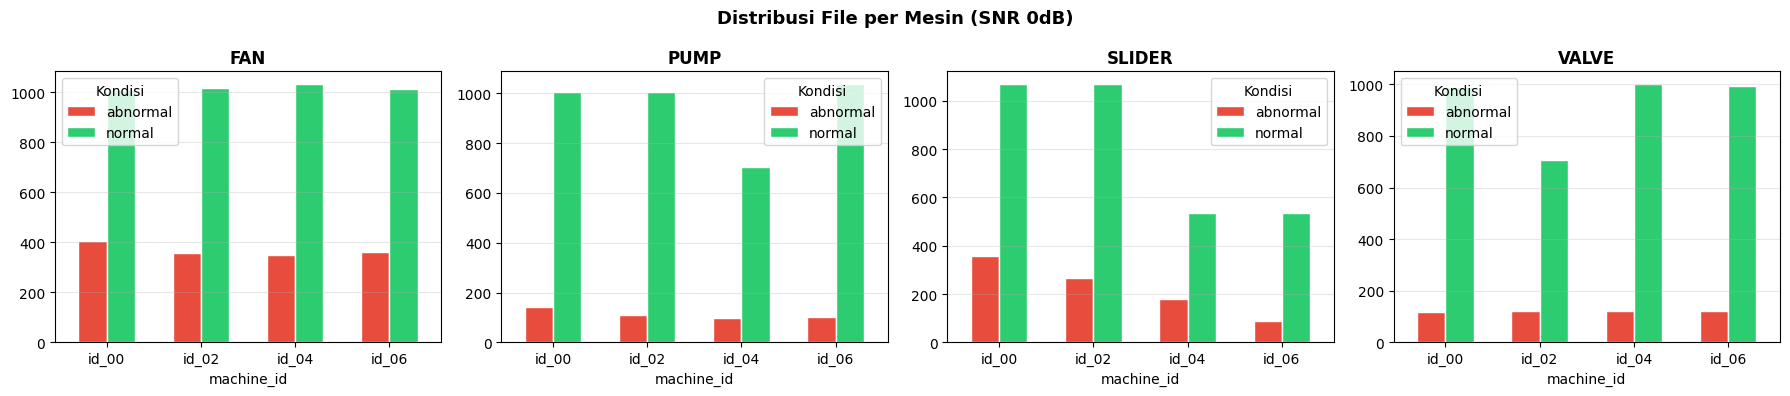

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribusi File per Mesin (SNR 0dB)', fontsize=13, fontweight='bold')
for ax, m in zip(axes, MACHINE_TYPES):
    pv = df[df['machine'] == m].groupby(['machine_id', 'condition'])['n_files'].sum().unstack(fill_value=0)
    colors = ['#2ecc71' if c == 'normal' else '#e74c3c' for c in pv.columns]
    pv.plot(kind='bar', ax=ax, color=colors, width=0.6, edgecolor='white')
    ax.set_title(m.upper(), fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Kondisi')
plt.tight_layout()
plt.savefig('/kaggle/working/file_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
def get_sample(m, cond='normal', mid='id_00'):
    base = os.path.join(DATASET_ROOT, f'{TARGET_SNR}_{m}', m, mid, cond)
    files = sorted(glob.glob(os.path.join(base, '*.wav')))
    return files[0] if files else None

path = get_sample('fan', 'normal')
wav, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
print(f'Loaded: {os.path.basename(path)}')
print(f'Durasi: {len(wav)/sr:.2f}s | SR: {sr}Hz | Shape: {wav.shape}')


Loaded: 00000000.wav
Durasi: 10.00s | SR: 16000Hz | Shape: (160000,)


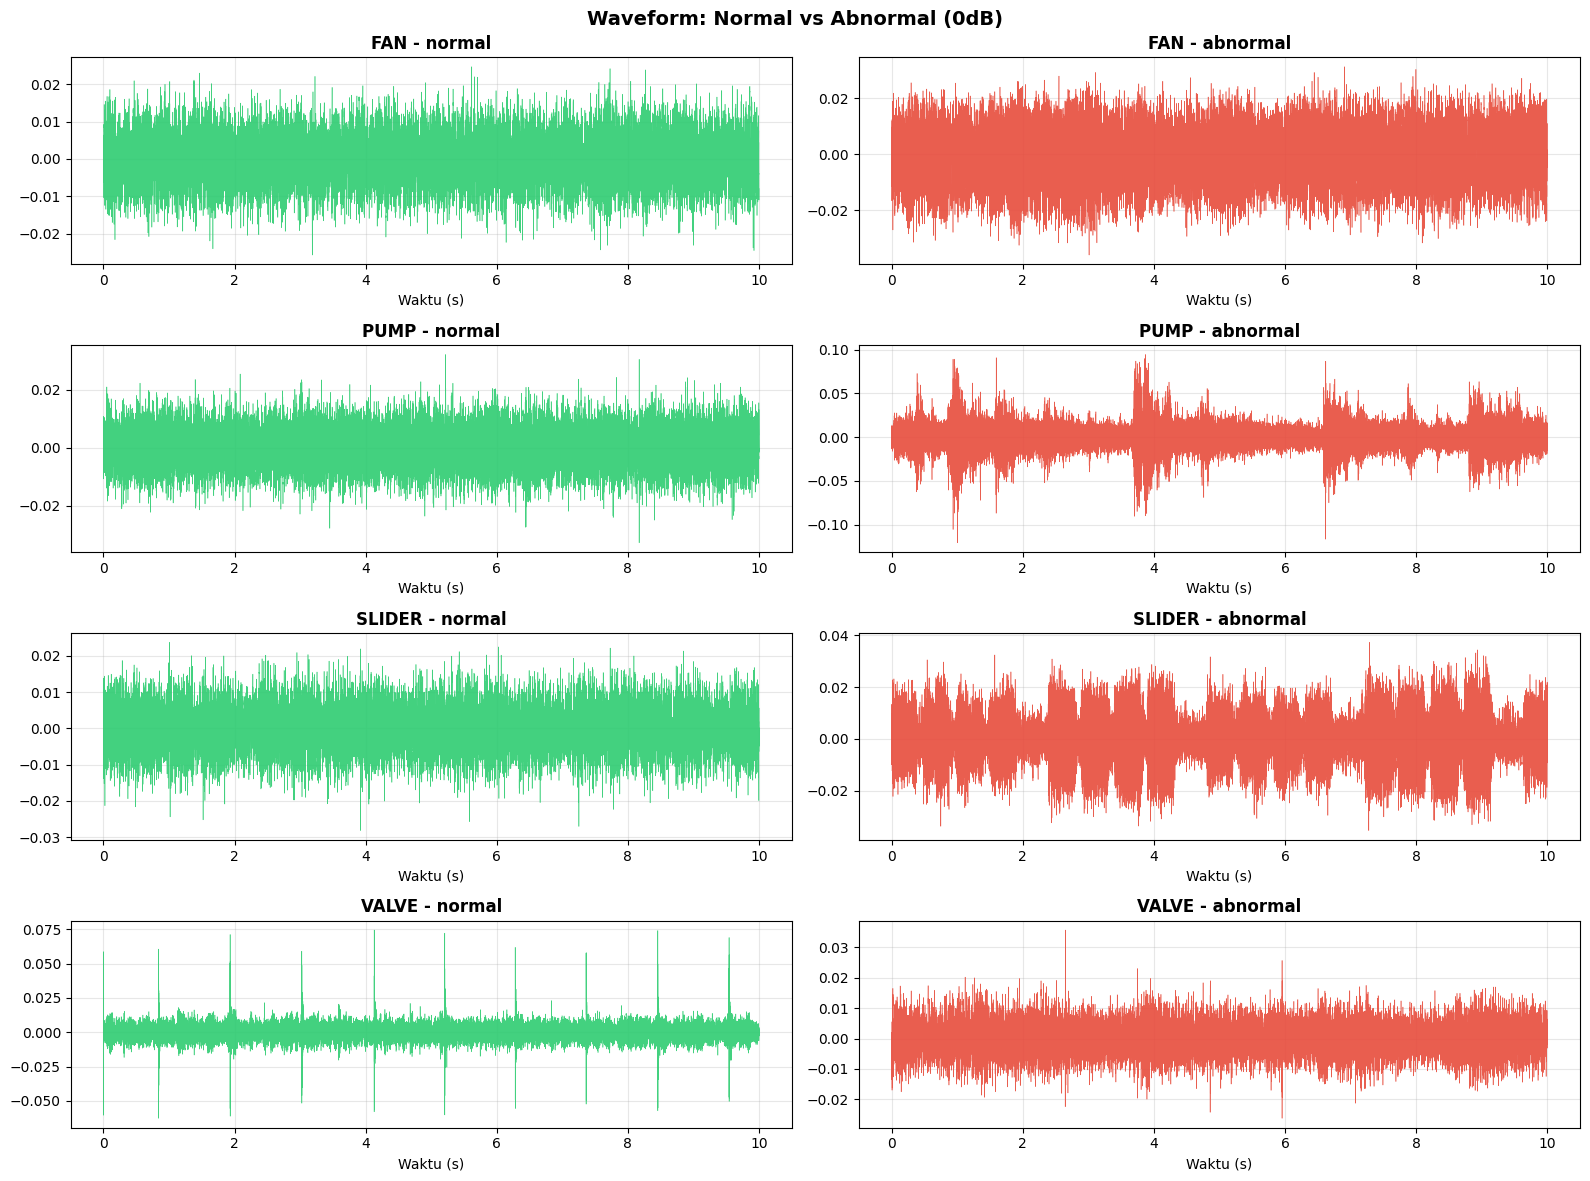

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Waveform: Normal vs Abnormal (0dB)', fontsize=14, fontweight='bold')
for row, m in enumerate(MACHINE_TYPES):
    for col, cond in enumerate(['normal', 'abnormal']):
        p = get_sample(m, cond)
        if not p:
            continue
        w, sr_ = librosa.load(p, sr=SAMPLE_RATE, mono=True)
        t = np.linspace(0, len(w)/sr_, len(w))
        color = '#2ecc71' if cond == 'normal' else '#e74c3c'
        ax = axes[row, col]
        ax.plot(t, w, color=color, lw=0.4, alpha=0.9)
        ax.set_title(f'{m.upper()} - {cond}', fontweight='bold')
        ax.set_xlabel('Waktu (s)')
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/waveforms.png', dpi=150, bbox_inches='tight')
plt.show()


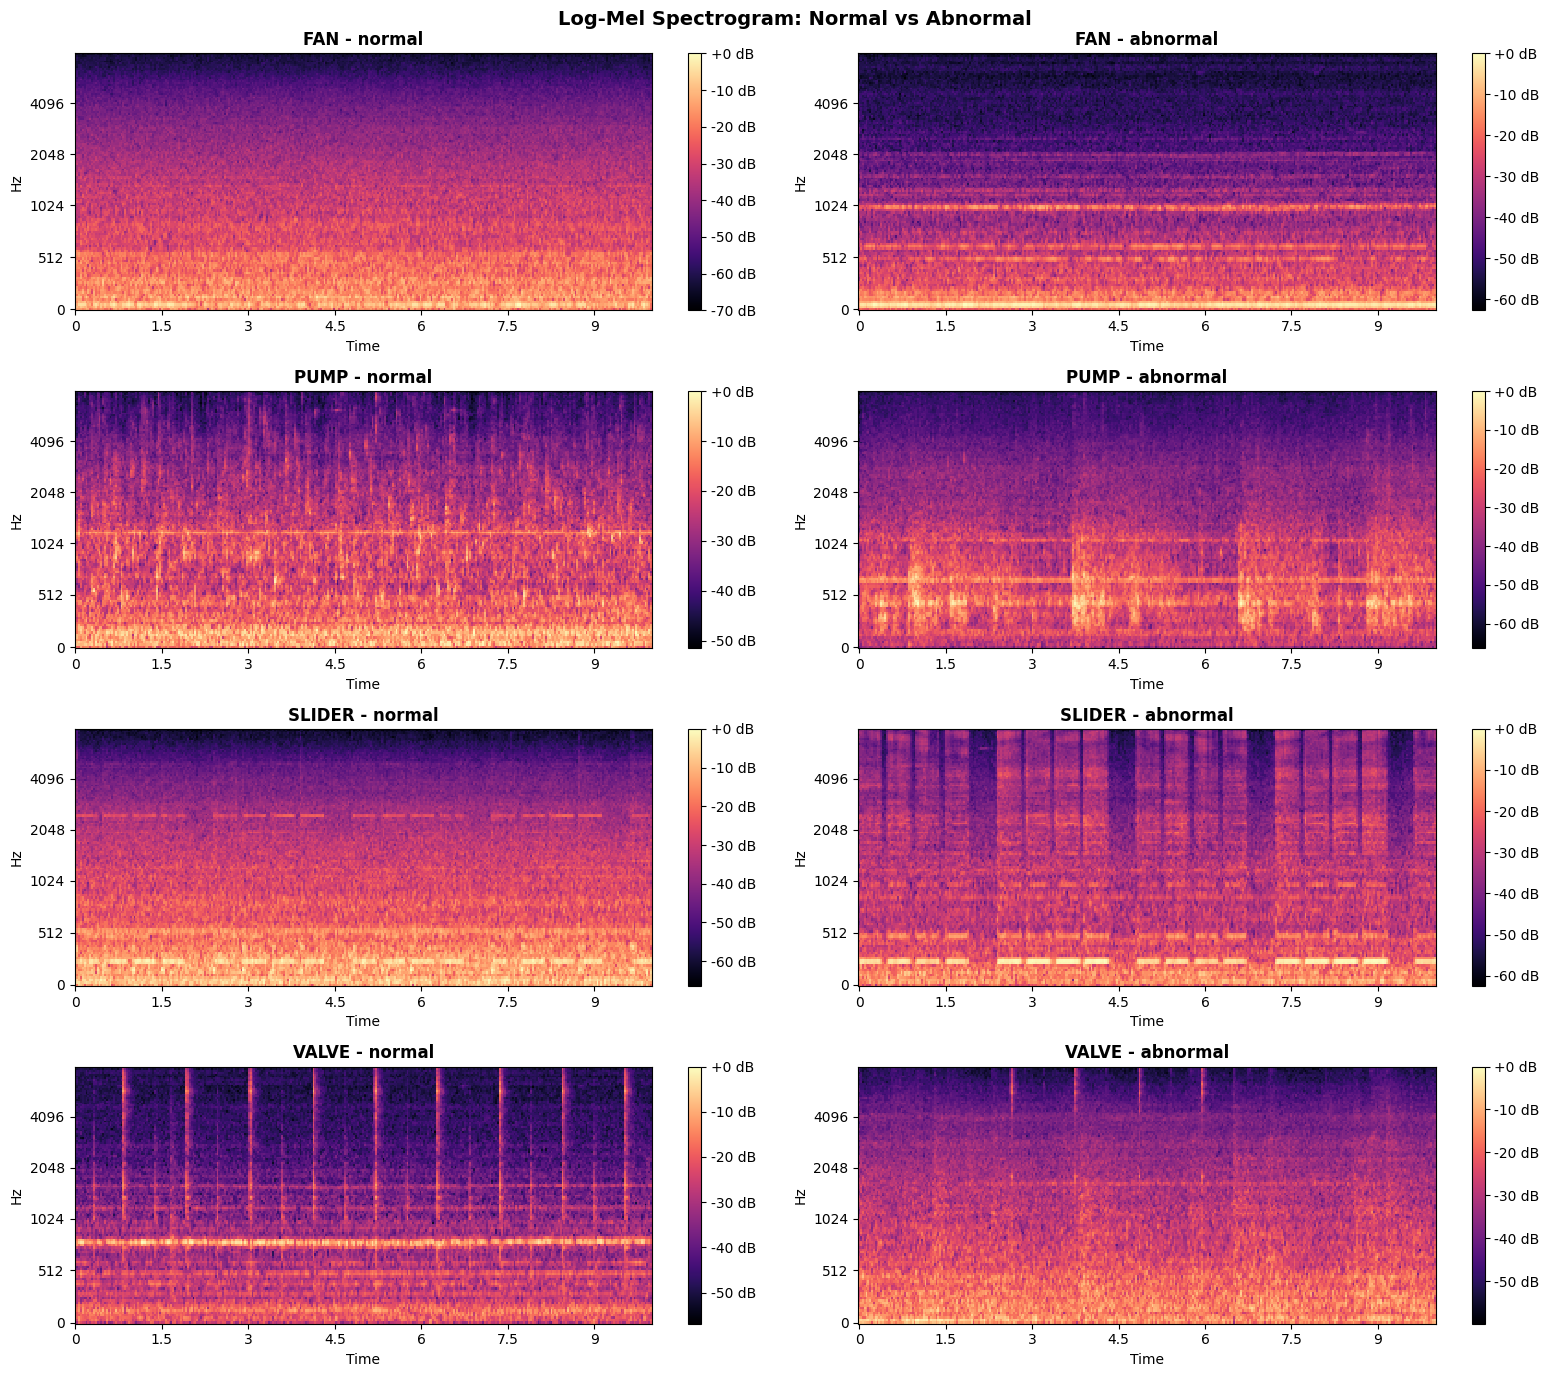

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Log-Mel Spectrogram: Normal vs Abnormal', fontsize=14, fontweight='bold')
for row, m in enumerate(MACHINE_TYPES):
    for col, cond in enumerate(['normal', 'abnormal']):
        p = get_sample(m, cond)
        if not p:
            continue
        w, sr_ = librosa.load(p, sr=SAMPLE_RATE, mono=True)
        mel = librosa.feature.melspectrogram(y=w, sr=sr_, n_mels=128, n_fft=1024, hop_length=512)
        spec = librosa.power_to_db(mel, ref=np.max)
        ax = axes[row, col]
        img = librosa.display.specshow(spec, sr=sr_, hop_length=512, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        ax.set_title(f'{m.upper()} - {cond}', fontweight='bold')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.savefig('/kaggle/working/mel_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
meta = {
    'dataset': 'MIMII',
    'link': 'https://www.kaggle.com/datasets/bisheshgiri/mimii-dataset',
    'model': 'STgram-MFN',
    'target_snr': TARGET_SNR,
    'machine_types': MACHINE_TYPES,
    'sample_rate': SAMPLE_RATE,
    'n_mels': 128,
    'n_fft': 1024,
    'hop_length': 512
}
with open('/kaggle/working/dataset_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('NB-01 SELESAI!')
print('Output:', sorted(os.listdir('/kaggle/working/')))
print('-> Lanjut ke NB-02_Preprocessing.ipynb')


NB-01 SELESAI!
Output: ['__notebook__.ipynb', 'dataset_meta.json', 'file_distribution.png', 'mel_spectrograms.png', 'waveforms.png']
-> Lanjut ke NB-02_Preprocessing.ipynb
